## **Data Augmentation Layer (for MNIST)**

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([   
    layers.RandomRotation(0.1),              
    layers.RandomZoom(0.1),                  
    
])

---
# **CNN (with Dropout & Data Augmentation)**

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1 Load Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Reshape to add channel dimension (28,28) -> (28,28,1)
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# 2 Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3 Data Augmentation
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# 4 Basic CNN Model
model = keras.Sequential([

    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

# 5 Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6 Train
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_test, y_test)
)

# 7 Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

Epoch 1/10


c:\Users\Jitesh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.9148 - loss: 0.2705 - val_accuracy: 0.9841 - val_loss: 0.0498
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9680 - loss: 0.1051 - val_accuracy: 0.9856 - val_loss: 0.0433
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9723 - loss: 0.0876 - val_accuracy: 0.9872 - val_loss: 0.0356
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9766 - loss: 0.0772 - val_accuracy: 0.9877 - val_loss: 0.0336
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.9788 - loss: 0.0695 - val_accuracy: 0.9882 - val_loss: 0.0331
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9806 - loss: 0.0611 - val_accuracy: 0.9887 - val_loss: 0.0301
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.9822 - loss: 0.0579 - val_accuracy: 0.9909 - val_loss: 0.0255
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9833 - loss: 0.0532 - val_accurac

## **Plot Training History**

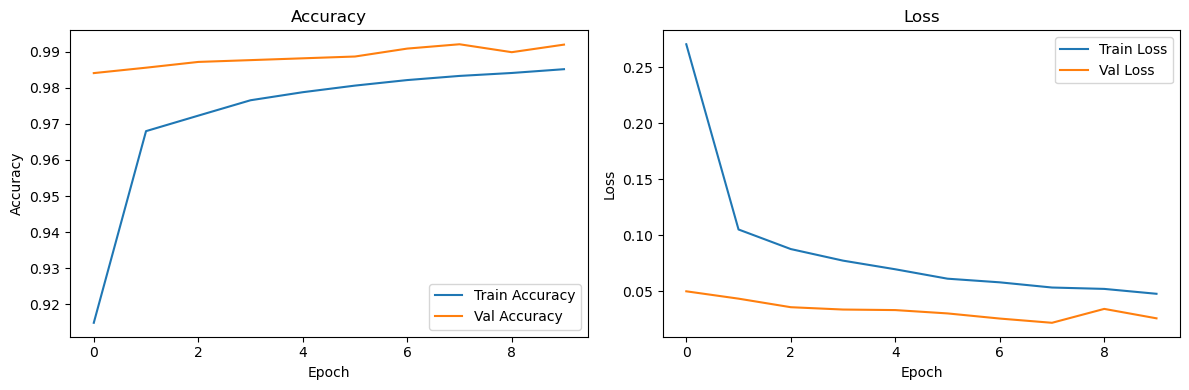

In [3]:
# Plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

---
# **UPLOAD YOUR OWN IMAGE FOR TESTING**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


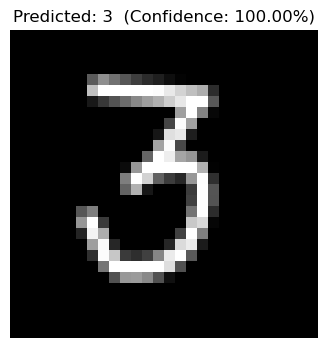


File: C:/Users/Jitesh/Downloads/mn.png
Predicted Digit: 3
Confidence: 100.00%

All class probabilities:
  Digit 0: 0.00%
  Digit 1: 0.00%
  Digit 2: 0.00%
  Digit 3: 100.00%
  Digit 4: 0.00%
  Digit 5: 0.00%
  Digit 6: 0.00%
  Digit 7: 0.00%
  Digit 8: 0.00%
  Digit 9: 0.00%


In [8]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

# --- Select image using file dialog (Local Jupyter) ---
root = tk.Tk()
root.withdraw()                    # Hide the main tkinter window
root.attributes('-topmost', True)  # Bring dialog to front

file_path = filedialog.askopenfilename(
    title='Select a handwritten digit image',
    filetypes=[('Image files', '*.png *.jpg *.jpeg *.bmp *.tiff')]
)
root.destroy()

if file_path:
    # Load the image
    img = Image.open(file_path)

    # Convert to grayscale
    img = img.convert('L')

    # Resize to 28x28
    img = img.resize((28, 28))

    # Convert to numpy array
    img_array = np.array(img)

    # MNIST has white digit on black background
    # If the uploaded image has dark digit on light background, invert it
    if np.mean(img_array) > 127:
        img_array = 255 - img_array

    # Normalize to 0-1
    img_array = img_array / 255.0

    # Reshape for model: (1, 28, 28, 1)
    img_input = img_array.reshape(1, 28, 28, 1)

    # Predict
    prediction = model.predict(img_input)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # Display
    plt.figure(figsize=(4, 4))
    plt.imshow(img_array, cmap='gray')
    plt.title(f"Predicted: {predicted_class}  (Confidence: {confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"\nFile: {file_path}")
    print(f"Predicted Digit: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"\nAll class probabilities:")
    for i in range(10):
        print(f"  Digit {i}: {prediction[0][i]*100:.2f}%")
else:
    print('No file selected.')